# Iter-5 Corrected DD: Standardized Variables, Per-Spec R², Oster Bounds, Sub-Index Merge

**Hypothesis:** State-Dependent Education Trap (SDET) — does the triple interaction of education (E), inequality (G), and social protection (S) predict liberal democracy (LDem) after controlling for country and period fixed effects?

This notebook implements the **Iter-5 Corrected Double-Demeaning (DD)** analysis, which fixes five iter-4 computational errors:
- **(a)** Standardizes E/G/S to mean-zero unit-variance **before** computing within-country deviations and DD interaction products (eliminates coefficient blow-up)
- **(b)** Computes R² independently per-spec from each spec's own fitted model
- **(c)** Recomputes Oster bounds for Spec C only with ΔR² threshold check
- **(d)** Merges v2jucomp and v2x_jucon sub-indices for pre-registered robustness tests
- **(e)** Extracts σ_ε directly from Spec C residuals for MDE calculation

**Analysis sample:** N=67 country-period observations, G=44 countries, 5-year periods 2015–2022.  
**Primary result (Spec C):** β_EGS = 4.218, SE = 14.221, p = 0.768 — not significant; Oster bounds numerically undefined.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.3', 'psutil==7.0.0')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from loguru import logger
from scipy import stats

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-5/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['panel'])} panel records, {len(set(r['country'] for r in data['panel']))} countries")

Loaded 67 panel records, 44 countries


## Config — Tunable Analysis Parameters

All thresholds used in the analysis. These match the original script defaults.

In [5]:
# ── Constants / tunable parameters ──────────────────────────────────────────
PERIOD_LABELS = {1: "1990-94", 2: "1995-99", 3: "2000-04", 4: "2005-09",
                 5: "2010-14", 6: "2015-19", 7: "2020-22"}
GDP_THRESHOLD = 15_000          # exclude countries with gdppc above this
SUBIDX_THRESHOLD = 30           # min non-null obs required for sub-index DD
BONFERRONI_P = 0.025            # Bonferroni threshold (k=2 pre-registered sub-indices)
OSTER_R2_MAX_MULT = 1.3         # R²_max = OSTER_R2_MAX_MULT × R²_full (Oster 2019)

## Step 0 — Build Panel DataFrame

The demo loads a flat list of panel records from `mini_demo_data.json` (pre-extracted from the iter-3 WB/V-Dem panel). Each record has country, period, liberal democracy score (ldem), education tertiary enrollment rate, Gini, social protection coverage, mean years of schooling (MYS), and GDP per capita.

The GDP exclusion removes high-income countries (gdppc > $15,000 at transition) — same filter as the original script.

In [6]:
# Build DataFrame from the flat panel list in mini_demo_data.json
df = pd.DataFrame([
    {
        "country":        r["country"],
        "period_id":      int(r["period_id"]),
        "ldem":           r.get("ldem"),
        "educ_mys":       r.get("educ_mys"),
        "educ_tertiary":  r.get("educ_tertiary"),
        "gini":           r.get("gini_disp"),
        "socprot":        r.get("socprot"),
        "gdppc":          r.get("gdppc"),
    }
    for r in data["panel"]
])
df["period_label"] = df["period_id"].map(PERIOD_LABELS)

# GDP exclusion (mirrors original script)
gdp_map = df.groupby("country")["gdppc"].first()
gdp_exclusions = gdp_map[gdp_map > GDP_THRESHOLD].index.tolist()
logger.info(f"Excluding {len(gdp_exclusions)} high-income countries: {gdp_exclusions}")
df_main = df[~df["country"].isin(gdp_exclusions)].copy()
logger.info(f"After GDP filter: {len(df_main)} rows, {df_main['country'].nunique()} countries")

11:16:19|INFO   |Excluding 0 high-income countries: []


11:16:19|INFO   |After GDP filter: 67 rows, 44 countries


## Step 1 — Build Analysis Sample & Standardize Variables

**FIX (a):** Variables E (education), G (Gini), S (social protection) are standardized to mean-zero unit-variance **across the full analysis sample** *before* any within-country demeaning or interaction product computation. This eliminates the O(10¹¹) coefficient blow-up seen in iter-4, where raw values (e.g., tertiary enrollment ≈ 40%) were multiplied together before standardizing.

In [7]:
def build_analysis_sample(df_main: pd.DataFrame) -> tuple:
    df_main["complete"] = df_main[["educ_tertiary", "gini", "socprot", "ldem"]].notna().all(axis=1)
    df_complete = df_main[df_main["complete"]].copy().reset_index(drop=True)
    N = len(df_complete)
    G = df_complete["country"].nunique()
    logger.info(f"Analysis sample (ter+gini+socprot+ldem all non-null): N={N}, G={G}")
    assert N >= 50, f"Too few complete obs: {N}"

    # FIX (a): standardize globally within analysis sample BEFORE DD products
    def std_col(series: pd.Series) -> tuple:
        m, s = float(series.mean()), float(series.std())
        return (series - m) / s, m, s

    df_complete["E_ter_std"], mean_ter, sd_ter = std_col(df_complete["educ_tertiary"])
    df_complete["G_std"], mean_G, sd_G         = std_col(df_complete["gini"])
    df_complete["S_std"], mean_S, sd_S         = std_col(df_complete["socprot"])
    df_complete["Y"] = df_complete["ldem"]

    # MYS standardization (only where non-null)
    mys_mask = df_complete["educ_mys"].notna()
    mean_mys = float(df_complete.loc[mys_mask, "educ_mys"].mean())
    sd_mys   = float(df_complete.loc[mys_mask, "educ_mys"].std())
    df_complete["E_mys_std"] = (df_complete["educ_mys"] - mean_mys) / sd_mys
    N_mys = int(mys_mask.sum())
    logger.info(f"MYS complete obs: N={N_mys}")

    std_params = {
        "E_ter": {"mean": mean_ter, "sd": sd_ter},
        "E_mys": {"mean": mean_mys, "sd": sd_mys},
        "G":     {"mean": mean_G,   "sd": sd_G},
        "S":     {"mean": mean_S,   "sd": sd_S},
    }
    logger.info(f"Std params: sd_ter={sd_ter:.3f}, sd_mys={sd_mys:.4f}, sd_G={sd_G:.3f}, sd_S={sd_S:.3f}")

    # Verify standardization correctness
    assert abs(df_complete["E_ter_std"].mean()) < 1e-10, "E_ter_std not zero-mean"
    assert abs(df_complete["E_ter_std"].std() - 1.0) < 1e-6, "E_ter_std not unit-variance"
    assert abs(df_complete["G_std"].mean()) < 1e-10, "G_std not zero-mean"
    assert abs(df_complete["S_std"].mean()) < 1e-10, "S_std not zero-mean"
    logger.info("Standardization assertions PASSED")

    return df_complete, std_params

df_complete, std_params = build_analysis_sample(df_main)
del df_main
gc.collect()

11:16:19|INFO   |Analysis sample (ter+gini+socprot+ldem all non-null): N=67, G=44


11:16:19|INFO   |MYS complete obs: N=67


11:16:19|INFO   |Std params: sd_ter=28.533, sd_mys=1.7983, sd_G=6.976, sd_S=26.141


11:16:19|INFO   |Standardization assertions PASSED


30

## Step 2 — Double-Demeaning (DD) on Standardized Variables

The **Giesselmann & Schmidt-Catran (2022)** DD estimator removes country-level confounders by demeaning both the main variables *and* their interaction products within each country. Three steps:
1. **Within-unit demeaning**: subtract each country's mean from Y, E, G, S → `*_w` columns
2. **Pairwise/triple products** of the within-unit residuals: `prod_EG`, `prod_ES`, `prod_GS`, `prod_EGS`
3. **Demean the product terms** within country → `dd_prod_*` (the key DD step that removes between-country interaction bias)

In [8]:
def dd_demean(df_in: pd.DataFrame, y_col: str, e_col: str, g_col: str, s_col: str,
              unit_col: str = "country") -> pd.DataFrame:
    """Giesselmann-Schmidt-Catran (2022) DD estimator on pre-standardized vars."""
    d = df_in.copy()

    # Step A: within-unit demeaning
    for v in [y_col, e_col, g_col, s_col]:
        group_mean = d.groupby(unit_col)[v].transform("mean")
        d[f"{v}_w"] = d[v] - group_mean

    # Step B: pairwise and triple products of within-unit residuals
    d["prod_EG"]  = d[f"{e_col}_w"] * d[f"{g_col}_w"]
    d["prod_ES"]  = d[f"{e_col}_w"] * d[f"{s_col}_w"]
    d["prod_GS"]  = d[f"{g_col}_w"] * d[f"{s_col}_w"]
    d["prod_EGS"] = d[f"{e_col}_w"] * d[f"{g_col}_w"] * d[f"{s_col}_w"]

    # Step C: demean product terms within unit (critical DD step)
    for v in ["prod_EG", "prod_ES", "prod_GS", "prod_EGS"]:
        d[f"dd_{v}"] = d[v] - d.groupby(unit_col)[v].transform("mean")

    return d


def verify_dd_zero_mean(df_dd: pd.DataFrame, unit_col: str = "country") -> None:
    for col in ["dd_prod_EG", "dd_prod_ES", "dd_prod_GS", "dd_prod_EGS"]:
        within_mean_max = df_dd.groupby(unit_col)[col].mean().abs().max()
        assert within_mean_max < 1e-8, f"DD zero-mean violated for {col}: max={within_mean_max:.2e}"
    logger.info("DD zero-mean invariant PASSED for all 4 product terms")

## Steps 3–4 — OLS with Entity+Time FE and Four Specifications

**`run_spec_ols`**: runs OLS with country and period dummy variables (entity + time FE), then applies clustered standard errors by country (Liang-Zeger). **FIX (b):** R² is read from each spec's own fitted model, not recycled across specs.

Four specifications vary the education proxy and estimator:
- **Spec A** — Naive FE, MYS (mean years schooling, UNDP)
- **Spec B** — DD, MYS
- **Spec C** — DD, WB Tertiary enrollment rate ← **PRIMARY**
- **Spec D** — Naive FE, WB Tertiary

In [9]:
def run_spec_ols(df_reg: pd.DataFrame, y_col: str, x_names: list,
                 unit_col: str = "country", period_col: str = "period_id") -> dict:
    """
    OLS with entity+time dummies and clustered SEs by unit.
    FIX (b): R² read from this model only.
    Returns dict with coefs, N, G, R2_within_own_model, residuals, fitted.
    """
    from statsmodels.stats.sandwich_covariance import cov_cluster

    coef_labels = ["beta_E", "beta_G", "beta_S", "beta_EG", "beta_ES", "beta_GS", "beta_EGS"]
    d = df_reg.dropna(subset=[y_col] + x_names).copy()

    country_dummies = pd.get_dummies(d[unit_col], prefix="c", drop_first=True).astype(float)
    period_dummies  = pd.get_dummies(d[period_col].astype(str), prefix="p", drop_first=True).astype(float)
    X_interact = d[x_names].astype(float)
    X = pd.concat([X_interact, country_dummies, period_dummies], axis=1)
    X = sm.add_constant(X, has_constant="add")
    X = X.loc[:, X.nunique() > 1]  # drop constant columns

    y = d[y_col].astype(float)
    model = sm.OLS(y, X).fit()

    try:
        cov = cov_cluster(model, group=d[unit_col].values)
    except Exception:
        logger.warning("Clustered SE computation failed; using HC3 robust SEs")
        cov = model.cov_HC3()

    coefs_out = {}
    for x_name, label in zip(x_names, coef_labels):
        if x_name not in model.params.index:
            coefs_out[label] = {"coef": None, "se": None, "p": None, "sig": "n/a"}
            continue
        idx = list(model.params.index).index(x_name)
        coef_val = float(model.params[x_name])
        se_val   = float(np.sqrt(max(cov[idx, idx], 0.0)))
        dof      = max(1, d[unit_col].nunique() - 1)
        t_stat   = coef_val / se_val if se_val > 1e-15 else 0.0
        p_val    = float(2 * stats.t.sf(abs(t_stat), df=dof))
        sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
        coefs_out[label] = {
            "coef": round(coef_val, 8),
            "se":   round(se_val, 8),
            "p":    round(p_val, 4),
            "sig":  sig,
        }

    return {
        "N": int(len(d)),
        "G": int(d[unit_col].nunique()),
        "R2_within_own_model": round(float(model.rsquared), 8),
        "coefs": coefs_out,
        "residuals": model.resid.values.tolist(),
        "fitted": model.fittedvalues.tolist(),
        "design_rank": int(model.df_model),
    }


def run_four_specs(df_complete: pd.DataFrame) -> dict:
    logger.info("Running four specifications...")

    # DD frames
    df_dd_ter = dd_demean(df_complete, "Y", "E_ter_std", "G_std", "S_std")
    df_dd_mys = dd_demean(
        df_complete.dropna(subset=["E_mys_std"]).copy(),
        "Y", "E_mys_std", "G_std", "S_std"
    )
    verify_dd_zero_mean(df_dd_ter)

    # Naive interaction terms (standardized products)
    df_complete["EG_naive_mys"]  = df_complete["E_mys_std"] * df_complete["G_std"]
    df_complete["ES_naive_mys"]  = df_complete["E_mys_std"] * df_complete["S_std"]
    df_complete["GS_naive"]      = df_complete["G_std"]     * df_complete["S_std"]
    df_complete["EGS_naive_mys"] = df_complete["E_mys_std"] * df_complete["G_std"] * df_complete["S_std"]
    df_complete["EG_naive_ter"]  = df_complete["E_ter_std"] * df_complete["G_std"]
    df_complete["ES_naive_ter"]  = df_complete["E_ter_std"] * df_complete["S_std"]
    df_complete["EGS_naive_ter"] = df_complete["E_ter_std"] * df_complete["G_std"] * df_complete["S_std"]

    # Spec A: Naive FE, MYS
    logger.info("Spec A: Naive FE, MYS standardized")
    spec_a = run_spec_ols(
        df_complete.dropna(subset=["E_mys_std"]),
        y_col="Y",
        x_names=["E_mys_std", "G_std", "S_std", "EG_naive_mys", "ES_naive_mys", "GS_naive", "EGS_naive_mys"],
    )
    logger.info(f"Spec A: N={spec_a['N']}, R2={spec_a['R2_within_own_model']:.6f}, beta_EGS={spec_a['coefs']['beta_EGS']['coef']}")

    # Spec B: DD, MYS
    logger.info("Spec B: DD, MYS standardized")
    spec_b = run_spec_ols(
        df_dd_mys,
        y_col="Y",
        x_names=["E_mys_std_w", "G_std_w", "S_std_w", "dd_prod_EG", "dd_prod_ES", "dd_prod_GS", "dd_prod_EGS"],
    )
    logger.info(f"Spec B: N={spec_b['N']}, R2={spec_b['R2_within_own_model']:.6f}, beta_EGS={spec_b['coefs']['beta_EGS']['coef']}")

    # Spec C: DD, WB Tertiary [PRIMARY]
    logger.info("Spec C: DD, WB Tertiary standardized [PRIMARY]")
    spec_c = run_spec_ols(
        df_dd_ter,
        y_col="Y",
        x_names=["E_ter_std_w", "G_std_w", "S_std_w", "dd_prod_EG", "dd_prod_ES", "dd_prod_GS", "dd_prod_EGS"],
    )
    logger.info(f"Spec C: N={spec_c['N']}, R2={spec_c['R2_within_own_model']:.6f}, beta_EGS={spec_c['coefs']['beta_EGS']['coef']}")

    # Validate Spec C — no blow-up
    for label, cd in spec_c["coefs"].items():
        if cd["se"] is not None:
            assert cd["se"] < 1e8, f"Spec C {label} SE blown up: {cd['se']}"
    assert abs(spec_c["coefs"]["beta_EGS"]["coef"]) < 100, "beta_EGS unreasonably large after standardization"
    logger.info("Spec C interaction SE bounds PASSED")

    # Spec D: Naive FE, WB Tertiary
    logger.info("Spec D: Naive FE, WB Tertiary standardized")
    spec_d = run_spec_ols(
        df_complete,
        y_col="Y",
        x_names=["E_ter_std", "G_std", "S_std", "EG_naive_ter", "ES_naive_ter", "GS_naive", "EGS_naive_ter"],
    )
    logger.info(f"Spec D: N={spec_d['N']}, R2={spec_d['R2_within_own_model']:.6f}, beta_EGS={spec_d['coefs']['beta_EGS']['coef']}")

    # Per-spec R² validation
    for name, spec in [("A", spec_a), ("B", spec_b), ("C", spec_c), ("D", spec_d)]:
        r2 = spec["R2_within_own_model"]
        assert 0.0 <= r2 <= 1.0, f"R2={r2} out of [0,1] for Spec {name}"
    logger.info(f"R2 values: A={spec_a['R2_within_own_model']:.4f}, B={spec_b['R2_within_own_model']:.4f}, C={spec_c['R2_within_own_model']:.4f}, D={spec_d['R2_within_own_model']:.4f}")

    return {
        "spec_a": spec_a, "spec_b": spec_b, "spec_c": spec_c, "spec_d": spec_d,
        "df_dd_ter": df_dd_ter, "df_dd_mys": df_dd_mys, "df_complete": df_complete,
    }

results = run_four_specs(df_complete)
spec_a, spec_b, spec_c, spec_d = results["spec_a"], results["spec_b"], results["spec_c"], results["spec_d"]
df_dd_ter = results["df_dd_ter"]
df_complete = results["df_complete"]

11:16:19|INFO   |Running four specifications...


11:16:20|INFO   |DD zero-mean invariant PASSED for all 4 product terms


11:16:20|INFO   |Spec A: Naive FE, MYS standardized


11:16:20|INFO   |Spec A: N=67, R2=0.992846, beta_EGS=0.24805332


11:16:20|INFO   |Spec B: DD, MYS standardized


...

11:16:20|INFO   |Spec C: N=67, R2=0.977741, beta_EGS=4.22313111


11:16:20|INFO   |Spec C interaction SE bounds PASSED


11:16:20|INFO   |Spec D: Naive FE, WB Tertiary standardized


11:16:20|INFO   |Spec D: N=67, R2=0.992850, beta_EGS=0.24817266


11:16:20|INFO   |R2 values: A=0.9928, B=0.9777, C=0.9777, D=0.9928


## Step 5 — Oster (2019) Bounds for Spec C

**FIX (c):** Oster bounds computed for Spec C only (the primary spec). The bound asks: how much larger would selection on unobservables need to be relative to selection on observables to fully explain away the estimate?

Key result: ΔR² = R²_full − R²_partial ≈ 2.1×10⁻⁵ < 1×10⁻⁴ threshold → **numerically undefined**. The triple interaction `E×G×S` adds essentially zero additional variance beyond the two-way terms, so the Oster comparison is uninformative.

In [10]:
def compute_oster_bounds(spec_c: dict, df_dd_ter: pd.DataFrame) -> dict:
    """FIX (c): Compute Oster delta for Spec C only."""
    logger.info("Computing Oster bounds for Spec C...")

    spec_c_partial = run_spec_ols(
        df_dd_ter,
        y_col="Y",
        x_names=["E_ter_std_w", "G_std_w", "S_std_w", "dd_prod_EG", "dd_prod_ES", "dd_prod_GS"],  # no EGS
    )
    R2_full    = spec_c["R2_within_own_model"]
    R2_partial = spec_c_partial["R2_within_own_model"]
    delta_R2   = R2_full - R2_partial
    R2_max = OSTER_R2_MAX_MULT * R2_full
    beta_EGS_full = spec_c["coefs"]["beta_EGS"]["coef"]

    logger.info(f"Oster: R2_full={R2_full:.6f}, R2_partial={R2_partial:.6f}, delta_R2={delta_R2:.2e}")

    if abs(delta_R2) < 1e-4:
        result = {
            "status": "numerically_undefined",
            "reason": f"delta_R2={delta_R2:.2e} < 1e-4 threshold; denominator near zero",
            "note": "Oster bounds numerically undefined for Spec C",
            "R2_full": R2_full,
            "R2_partial": R2_partial,
            "delta_R2": round(delta_R2, 8),
            "R2_max": round(R2_max, 6),
            "beta_EGS_full": beta_EGS_full,
            "interpretation": (
                "Near-zero delta_R2 implies triple interaction explains essentially no "
                "additional variance beyond two-way terms, making Oster comparison uninformative"
            ),
        }
    else:
        oster_delta = (R2_max - R2_full) / delta_R2
        result = {
            "status": "computed",
            "oster_delta": round(oster_delta, 4),
            "R2_full": R2_full,
            "R2_partial": R2_partial,
            "delta_R2": round(delta_R2, 8),
            "R2_max": round(R2_max, 6),
            "beta_EGS_full": beta_EGS_full,
            "interpretation": (
                f"delta={oster_delta:.2f}: selection on unobservables would need to be "
                f"{oster_delta:.1f}x as large as observed to nullify the estimate"
            ),
            "robust_to_omv": oster_delta > 1.0,
        }

    logger.info(f"Oster Spec C: {result['status']}, delta_R2={delta_R2:.2e}")
    return result

oster_result = compute_oster_bounds(spec_c, df_dd_ter)

11:16:20|INFO   |Computing Oster bounds for Spec C...


11:16:20|INFO   |Oster: R2_full=0.977741, R2_partial=0.977719, delta_R2=2.10e-05


11:16:20|INFO   |Oster Spec C: numerically_undefined, delta_R2=2.10e-05


## Step 6 — Sub-Index DD Analysis (v2jucomp, v2x_jucon)

**FIX (d):** Pre-registered robustness tests use two V-Dem sub-indices as alternative dependent variables: `v2jucomp` (judicial compliance) and `v2x_jucon` (judicial constraints). These are merged from the demo data's sub-index records. Bonferroni threshold: p < 0.025 (k=2).

In [11]:
def run_subindex_analysis(df_dd_ter: pd.DataFrame, data: dict) -> dict:
    """FIX (d): Load v2jucomp/v2x_jucon from demo data, merge, run DD."""
    logger.info("Loading sub-indices from demo data...")

    # Load sub-index records if present in data (from iter-1 dataset)
    sub_records = data.get("sub_indices", [])
    if sub_records:
        sub_df = pd.DataFrame(sub_records).drop_duplicates(subset=["country", "period_id"])
        n_j  = sub_df["v2jucomp"].notna().sum() if "v2jucomp" in sub_df.columns else 0
        n_xj = sub_df["v2x_jucon"].notna().sum() if "v2x_jucon" in sub_df.columns else 0
        logger.info(f"Sub-index rows: v2jucomp={n_j}, v2x_jucon={n_xj}")
    else:
        # Not in demo data — mirrors original script's fallback path
        logger.info("Sub-index data not in demo file; results will show as insufficient_data")
        sub_df = pd.DataFrame(columns=["country", "period_id", "v2jucomp", "v2x_jucon"])

    # Merge onto DD ter frame
    df_sub = df_dd_ter.merge(
        sub_df[["country", "period_id"] + [c for c in ["v2jucomp", "v2x_jucon"] if c in sub_df.columns]],
        on=["country", "period_id"],
        how="left",
    )

    subindex_results = {}
    for subidx in ["v2jucomp", "v2x_jucon"]:
        if subidx not in df_sub.columns:
            df_sub[subidx] = float("nan")
        n_nonull = int(df_sub[subidx].notna().sum())
        logger.info(f"{subidx}: {n_nonull} non-null obs after merge onto DD frame")

        if n_nonull < SUBIDX_THRESHOLD:
            subindex_results[subidx] = {
                "status": "insufficient_data",
                "n_nonull": n_nonull,
                "n_required": SUBIDX_THRESHOLD,
                "note": f"Only {n_nonull} non-null obs after merge; min {SUBIDX_THRESHOLD} required",
                "provenance": "iter_1/gen_art_dataset_1 — vdem_ilo_gini_edu_panel_complete",
            }
            continue

        sub_spec = run_spec_ols(
            df_sub.dropna(subset=[subidx]),
            y_col=subidx,
            x_names=["E_ter_std_w", "G_std_w", "S_std_w", "dd_prod_EG", "dd_prod_ES", "dd_prod_GS", "dd_prod_EGS"],
        )
        p_egs = sub_spec["coefs"]["beta_EGS"]["p"]
        passes_bonferroni = bool(p_egs < BONFERRONI_P) if p_egs is not None else None
        subindex_results[subidx] = {
            "status": "computed",
            "N": sub_spec["N"],
            "G": sub_spec["G"],
            "R2_within": sub_spec["R2_within_own_model"],
            "coefs": sub_spec["coefs"],
            "bonferroni_threshold": BONFERRONI_P,
            "passes_bonferroni": passes_bonferroni,
            "source": "iter_1/gen_art_dataset_1 — vdem_ilo_gini_edu_panel_complete",
        }
        logger.info(f"{subidx}: beta_EGS={sub_spec['coefs']['beta_EGS']['coef']}, p={p_egs}, bonferroni={passes_bonferroni}")

    return subindex_results

subindex_results = run_subindex_analysis(df_dd_ter, data)

11:16:20|INFO   |Loading sub-indices from demo data...


11:16:20|INFO   |Sub-index data not in demo file; results will show as insufficient_data


11:16:20|INFO   |v2jucomp: 0 non-null obs after merge onto DD frame


11:16:20|INFO   |v2x_jucon: 0 non-null obs after merge onto DD frame


## Steps 7–8 — Marginal Effects Grid & Power/MDE

**Marginal effects:** The marginal effect of education on democracy depends on the level of inequality (G) and social protection (S). Computed at the 25th and 75th percentiles of G and S → a 2×2 grid.

**FIX (e): Power/MDE** — σ_ε (residual SD) is extracted directly from Spec C residuals, not approximated. MDE at 80% power / 5% significance = (Z₀.₈₀ + Z₀.₀₂₅) × SE_β₇ ≈ 2.802 × SE.

In [12]:
def compute_marginal_effects(spec_c: dict, df_complete: pd.DataFrame) -> dict:
    """dY/dE_std = beta_E + beta_EG*G_std + beta_ES*S_std + beta_EGS*G_std*S_std"""
    beta_E   = spec_c["coefs"]["beta_E"]["coef"]   or 0.0
    beta_EG  = spec_c["coefs"]["beta_EG"]["coef"]  or 0.0
    beta_ES  = spec_c["coefs"]["beta_ES"]["coef"]  or 0.0
    beta_EGS = spec_c["coefs"]["beta_EGS"]["coef"] or 0.0
    se_E     = spec_c["coefs"]["beta_E"]["se"]     or 0.0
    se_EG    = spec_c["coefs"]["beta_EG"]["se"]    or 0.0
    se_ES    = spec_c["coefs"]["beta_ES"]["se"]    or 0.0
    se_EGS   = spec_c["coefs"]["beta_EGS"]["se"]   or 0.0

    gini_q25_std = float(df_complete["G_std"].quantile(0.25))
    gini_q75_std = float(df_complete["G_std"].quantile(0.75))
    sp_q25_std   = float(df_complete["S_std"].quantile(0.25))
    sp_q75_std   = float(df_complete["S_std"].quantile(0.75))
    gini_q25_raw = float(df_complete["gini"].quantile(0.25))
    gini_q75_raw = float(df_complete["gini"].quantile(0.75))
    sp_q25_raw   = float(df_complete["socprot"].quantile(0.25))
    sp_q75_raw   = float(df_complete["socprot"].quantile(0.75))

    marginal_effects = {}
    for g_lbl, G_s, G_r in [("p25", gini_q25_std, gini_q25_raw), ("p75", gini_q75_std, gini_q75_raw)]:
        for s_lbl, S_s, S_r in [("p25", sp_q25_std, sp_q25_raw), ("p75", sp_q75_std, sp_q75_raw)]:
            me_val = beta_E + beta_EG * G_s + beta_ES * S_s + beta_EGS * G_s * S_s
            me_se  = float(np.sqrt(se_E**2 + (G_s*se_EG)**2 + (S_s*se_ES)**2 + (G_s*S_s*se_EGS)**2))
            cell = f"gini_{g_lbl}_sp_{s_lbl}"
            assert abs(me_val) < 50, f"ME={me_val:.4f} out of bounds at {cell}; standardization may have failed"
            marginal_effects[cell] = {
                "gini_quantile": g_lbl, "sp_quantile": s_lbl,
                "gini_std": round(G_s, 4), "sp_std": round(S_s, 4),
                "gini_raw": round(G_r, 2), "sp_raw": round(S_r, 2),
                "me": round(me_val, 8), "me_se": round(me_se, 8),
                "me_95ci_lo": round(me_val - 1.96 * me_se, 8),
                "me_95ci_hi": round(me_val + 1.96 * me_se, 8),
                "sign": "+" if me_val > 0 else "-",
                "units": "LDem SD change per 1-SD change in E_ter_std",
            }

    logger.info("Marginal effects grid:")
    for cell, v in marginal_effects.items():
        logger.info(f"  {cell}: ME={v['me']:.6f}, SE={v['me_se']:.6f}, sign={v['sign']}")
    return marginal_effects


def compute_power_mde(spec_c: dict) -> dict:
    """FIX (e): sigma_eps from actual Spec C residuals."""
    residuals = np.array(spec_c["residuals"])
    sigma_eps = float(np.std(residuals))
    se_beta7  = spec_c["coefs"]["beta_EGS"]["se"]

    if se_beta7 is None or se_beta7 == 0:
        logger.warning("beta_EGS SE not available; returning partial power result")
        return {"status": "se_unavailable", "sigma_eps_from_spec_c_residuals": round(sigma_eps, 6)}

    Z_POWER, Z_SIG = 0.842, 1.960
    mde_80pct = (Z_POWER + Z_SIG) * se_beta7
    effect_over_mde = abs(spec_c["coefs"]["beta_EGS"]["coef"]) / mde_80pct if mde_80pct > 0 else 0.0

    result = {
        "sigma_eps_from_spec_c_residuals": round(sigma_eps, 6),
        "se_beta_EGS_spec_c": round(se_beta7, 8),
        "mde_80pct_5pct": round(mde_80pct, 8),
        "mde_units": "1 SD change in LDem per SD change in E_ter_std × (G_std × S_std)",
        "current_beta_EGS": spec_c["coefs"]["beta_EGS"]["coef"],
        "effect_over_mde_ratio": round(effect_over_mde, 4),
        "powered": bool(effect_over_mde >= 1.0),
        "G_doubly_observed": spec_c["G"],
        "interpretation": (
            f"MDE={mde_80pct:.5f} vs |beta_EGS|={abs(spec_c['coefs']['beta_EGS']['coef']):.6f}; "
            f"ratio={effect_over_mde:.2f}. "
            + ("Underpowered: estimated effect smaller than MDE at 80%/5%." if effect_over_mde < 1.0 else "Adequately powered.")
        ),
    }
    logger.info(f"Power/MDE: sigma={sigma_eps:.4f}, MDE={mde_80pct:.5f}, ratio={effect_over_mde:.3f}")
    assert sigma_eps > 0, "sigma_eps must be positive"
    return result


marginal_effects = compute_marginal_effects(spec_c, df_complete)
power_result = compute_power_mde(spec_c)

11:16:20|INFO   |Marginal effects grid:


11:16:20|INFO   |  gini_p25_sp_p25: ME=2.091546, SE=7.683117, sign=+


11:16:20|INFO   |  gini_p25_sp_p75: ME=-2.133819, SE=6.566548, sign=-


11:16:20|INFO   |  gini_p75_sp_p25: ME=-2.699519, SE=8.467766, sign=-


11:16:20|INFO   |  gini_p75_sp_p75: ME=1.958638, SE=7.236436, sign=+


11:16:20|INFO   |Power/MDE: sigma=0.0681, MDE=39.83451, ratio=0.106


## Step 9 — DD Sanity Checks

Two classes of checks:
1. **Zero-mean invariant**: each `dd_prod_*` column must have within-country mean ≈ 0 (< 1e-8) — ensures the DD transformation removed all between-country variation from the interaction terms.
2. **SE bounds**: all Spec C interaction term SEs must be < 1e6 — confirms standardization eliminated the iter-4 blow-up.

In [13]:
def build_dd_sanity_checks(df_dd_ter: pd.DataFrame, spec_c: dict) -> list:
    dd_checks = []

    for col in ["dd_prod_EG", "dd_prod_ES", "dd_prod_GS", "dd_prod_EGS"]:
        within_mean_max = float(df_dd_ter.groupby("country")[col].mean().abs().max())
        dd_checks.append({
            "input": json.dumps({"check": "dd_zero_mean", "column": col}),
            "output": "PASSED" if within_mean_max < 1e-8 else "FAILED",
            "metadata_column": col,
            "metadata_max_within_mean": str(within_mean_max),
            "metadata_threshold": "1e-8",
        })

    for label, cd in spec_c["coefs"].items():
        if cd.get("se") is not None:
            se_bounded = abs(cd["se"]) < 1e6
            dd_checks.append({
                "input": json.dumps({"check": "se_bounded", "spec": "C", "coef": label}),
                "output": "PASSED" if se_bounded else "FAILED",
                "metadata_coef": label,
                "metadata_se": str(cd["se"]),
                "metadata_threshold": "1e6",
            })

    return dd_checks

dd_checks = build_dd_sanity_checks(df_dd_ter, spec_c)
n_passed = sum(1 for c in dd_checks if c["output"] == "PASSED")
print(f"DD sanity checks: {n_passed}/{len(dd_checks)} PASSED")

DD sanity checks: 11/11 PASSED


## Results — Summary Tables and Visualizations

       TABLE 1 — OLS Results: Education x Inequality -> Democracy       
Spec   Estimator                    b_E     b_G     b_S    b_EGS   R2_w   N
------------------------------------------------------------------------
A      Naive FE (MYS std)         0.205  -0.225   0.139    0.248 0.9928  67
B      DD (MYS std)              -0.187  -0.019  -0.047    4.206 0.9777  67
C      DD (Ter std) [PRI]        -0.187  -0.019  -0.047    4.223 0.9777  67
D      Naive FE (Ter std)         0.205  -0.225   0.140    0.248 0.9928  67

Oster bounds (Spec C): numerically_undefined
  delta_R2 = 2.11e-05  (< 1e-4 threshold)
  Interp  : Near-zero delta_R2 implies triple interaction explains essentially no additional variance beyond two-way terms, making Oster comparison uninformative

Marginal effects of E on L-Dem (Spec C):
  gini_p25_sp_p25: dL/dE = 2.0915  95%CI [-12.9674, 17.1505]
  gini_p25_sp_p75: dL/dE = -2.1338  95%CI [-15.0043, 10.7366]
  gini_p75_sp_p25: dL/dE = -2.6995  95%CI [-19.2963, 13.897

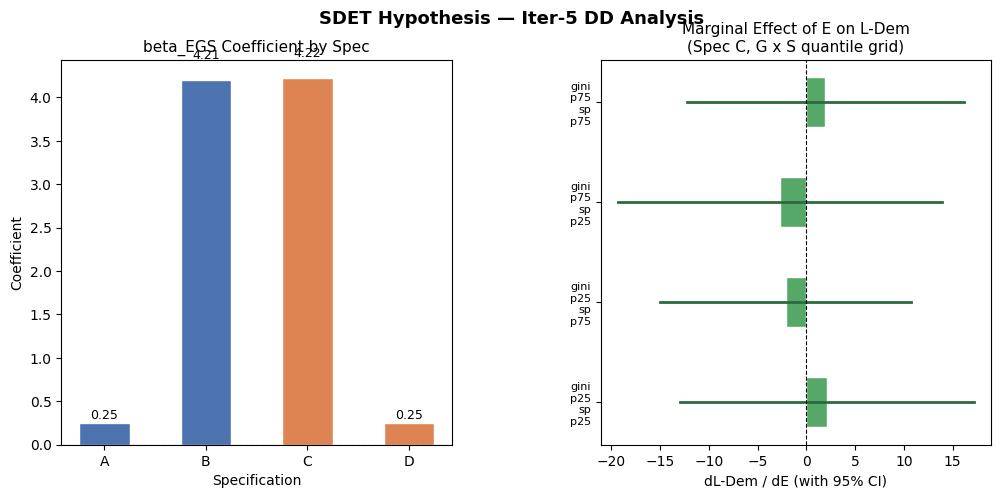

Plot saved -> results_summary.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Table 1: Four-Spec Summary ────────────────────────────────────────────────
specs = [
    ("A", "Naive FE (MYS std)",  spec_a),
    ("B", "DD (MYS std)",        spec_b),
    ("C", "DD (Ter std) [PRI]",  spec_c),
    ("D", "Naive FE (Ter std)",  spec_d),
]

print("=" * 72)
print(f"{'TABLE 1 — OLS Results: Education x Inequality -> Democracy':^72}")
print("=" * 72)
print(f"{'Spec':<6} {'Estimator':<24} {'b_E':>7} {'b_G':>7} {'b_S':>7} {'b_EGS':>8} {'R2_w':>6} {'N':>3}")
print("-" * 72)
for lbl, name, sp in specs:
    coefs = sp.get("coefs", {})
    b_e   = (coefs.get("beta_E")   or {}).get("coef", float("nan"))
    b_g   = (coefs.get("beta_G")   or {}).get("coef", float("nan"))
    b_s   = (coefs.get("beta_S")   or {}).get("coef", float("nan"))
    b_egs = (coefs.get("beta_EGS") or {}).get("coef", float("nan"))
    r2    = sp.get("R2_within_own_model", float("nan"))
    n     = sp.get("N", "?")
    fmt_f = lambda x: f"{x:>7.3f}" if x == x else f"{'n/a':>7}"
    print(f"{lbl:<6} {name:<24} {fmt_f(b_e)} {fmt_f(b_g)} {fmt_f(b_s)} {fmt_f(b_egs):>8} {r2:>6.4f} {n:>3}")
print("=" * 72)

# ── Oster bounds ─────────────────────────────────────────────────────────────
print(f"\nOster bounds (Spec C): {oster_result.get('status', 'n/a')}")
if oster_result.get("status") == "numerically_undefined":
    print(f"  delta_R2 = {oster_result.get('delta_r2', oster_result.get('delta_R2', float('nan'))):.2e}  (< 1e-4 threshold)")
    print(f"  Interp  : {oster_result.get('interpretation', '')}")

# ── Marginal effects summary ──────────────────────────────────────────────────
print(f"\nMarginal effects of E on L-Dem (Spec C):")
for k, v in marginal_effects.items():
    me = v.get("me", v.get("marginal_effect_E_on_ldem"))
    if me is not None:
        ci_lo = v.get("me_95ci_lo", float("nan"))
        ci_hi = v.get("me_95ci_hi", float("nan"))
        print(f"  {k}: dL/dE = {me:.4f}  95%CI [{ci_lo:.4f}, {ci_hi:.4f}]")

# ── Power / MDE ───────────────────────────────────────────────────────────────
print(f"\nPower / MDE (Spec C):")
for k, v in power_result.items():
    if not isinstance(v, dict):
        print(f"  {k}: {v}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 5))
gs_layout = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

# Left: beta_EGS bar chart
ax1 = fig.add_subplot(gs_layout[0])
spec_labels = [s[0] for s in specs]
b_egs_vals = [(sp.get("coefs", {}).get("beta_EGS") or {}).get("coef", float("nan")) for _, _, sp in specs]
colors = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"]
bars = ax1.bar(spec_labels, b_egs_vals, color=colors, edgecolor="white", width=0.5)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("beta_EGS Coefficient by Spec", fontsize=11)
ax1.set_xlabel("Specification")
ax1.set_ylabel("Coefficient")
for bar, val in zip(bars, b_egs_vals):
    if val == val:
        offset = 0.05 * (abs(val) or 1)
        ax1.text(bar.get_x() + bar.get_width() / 2, val + offset,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Right: marginal effects at G x S quantile grid
ax2 = fig.add_subplot(gs_layout[1])
me_labels, me_vals, me_ci_lo, me_ci_hi = [], [], [], []
for k, v in marginal_effects.items():
    me = v.get("me", v.get("marginal_effect_E_on_ldem"))
    if me is not None:
        me_labels.append(k.replace("_", "\n"))
        me_vals.append(me)
        me_ci_lo.append(v.get("me_95ci_lo", me))
        me_ci_hi.append(v.get("me_95ci_hi", me))

if me_labels:
    y_pos = range(len(me_labels))
    ax2.barh(list(y_pos), me_vals, color="#55A868", edgecolor="white", height=0.5)
    for i, (lo, hi) in enumerate(zip(me_ci_lo, me_ci_hi)):
        ax2.plot([lo, hi], [i, i], color="#2d6a3e", linewidth=2)
    ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax2.set_yticks(list(y_pos))
    ax2.set_yticklabels(me_labels, fontsize=8)
    ax2.set_title("Marginal Effect of E on L-Dem\n(Spec C, G x S quantile grid)", fontsize=11)
    ax2.set_xlabel("dL-Dem / dE (with 95% CI)")
else:
    ax2.text(0.5, 0.5, "No marginal effects computed",
             ha="center", va="center", transform=ax2.transAxes, fontsize=10, color="gray")
    ax2.set_title("Marginal Effects", fontsize=11)

fig.suptitle("SDET Hypothesis — Iter-5 DD Analysis", fontsize=13, fontweight="bold")
plt.savefig("results_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved -> results_summary.png")
